Iter 1: interval = [0.0, 1.0], c = 0.5, f(c) = 0.375, error = None (first step)
Iter 2: interval = [0.0, 0.5], c = 0.25, f(c) = -1.921875, error = 1.0
Iter 3: interval = [0.25, 0.5], c = 0.375, f(c) = -0.681640625, error = 0.3333333333333333
Iter 4: interval = [0.375, 0.5], c = 0.4375, f(c) = -0.131103515625, error = 0.14285714285714285
Iter 5: interval = [0.4375, 0.5], c = 0.46875, f(c) = 0.127410888671875, error = 0.06666666666666667
Iter 6: interval = [0.4375, 0.46875], c = 0.453125, f(c) = -0.000469207763671875, error = 0.034482758620689655
Iter 7: interval = [0.453125, 0.46875], c = 0.4609375, f(c) = 0.06381368637084961, error = 0.01694915254237288
Iter 8: interval = [0.453125, 0.4609375], c = 0.45703125, f(c) = 0.031758129596710205, error = 0.008547008547008548
Iter 9: interval = [0.453125, 0.45703125], c = 0.455078125, f(c) = 0.01566595584154129, error = 0.004291845493562232
Iter 10: interval = [0.453125, 0.455078125], c = 0.4541015625, f(c) = 0.007603750564157963, error = 0.002

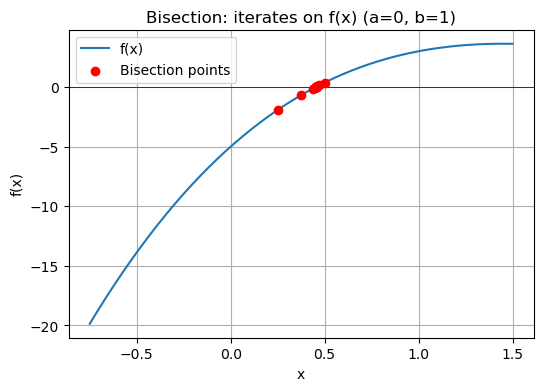

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# symbolic definition of f
x_sym = sp.symbols('x')
f_sym = x_sym**3 - 7*x_sym**2 + 14*x_sym - 5
f = sp.lambdify(x_sym, f_sym, 'numpy')   # numeric version
def bisection_simple():
    a = 0.0
    b = 1.0
    max_iter = int(input("Enter max number of iterations for bisection: "))
    tol = 1e-8

    fa = f(a)
    fb = f(b)
    if fa * fb > 0:
        print("Bisection error: f(a) and f(b) must have opposite signs.")
        return
    xs = []   # c_k values (x–coordinates)
    fs = []   # f(c_k)

    c_old = None
    for k in range(max_iter):
        c = 0.5 * (a + b)
        fc = f(c)

        xs.append(c)
        fs.append(fc)

        # relative error and printout, including current interval [a,b]
        if c_old is None:
            rel_err = None
            print(f"Iter {k+1}: interval = [{a}, {b}], c = {c}, f(c) = {fc}, error = None (first step)")
        else:
            rel_err = abs(c - c_old) / max(abs(c), 1e-16)
            print(f"Iter {k+1}: interval = [{a}, {b}], c = {c}, f(c) = {fc}, error = {rel_err}")

        # stopping criterion
        if c_old is not None and rel_err < tol:
            print(f"Root approximation: {c} after {k+1} iterations")
            break

        # interval update
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

        c_old = c
    # plot f(x) vs x, with bisection points on the curve
    x_min = min(xs + [a, b]) - 1
    x_max = max(xs + [a, b]) + 1
    x_plot = np.linspace(x_min, x_max, 400)
    y_plot = f(x_plot)

    plt.figure(figsize=(6, 4))
    plt.axhline(0, color='black', linewidth=0.5)
    plt.plot(x_plot, y_plot, label='f(x)')
    plt.scatter(xs, fs, color='red', zorder=3, label='Bisection points')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Bisection: iterates on f(x) (a=0, b=1)')
    plt.legend()
    plt.grid(True)
    plt.show()

bisection_simple()

